
===== MODEL PERFORMANCE =====
Accuracy : 0.6051282051282051
Precision: 0.5675675675675675
Recall   : 0.4827586206896552
F1 Score : 0.5217391304347826
ROC AUC  : 0.6297360578969775

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.63      0.70      0.66       108
           1       0.57      0.48      0.52        87

    accuracy                           0.61       195
   macro avg       0.60      0.59      0.59       195
weighted avg       0.60      0.61      0.60       195



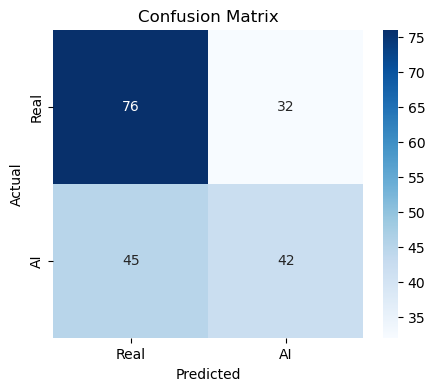

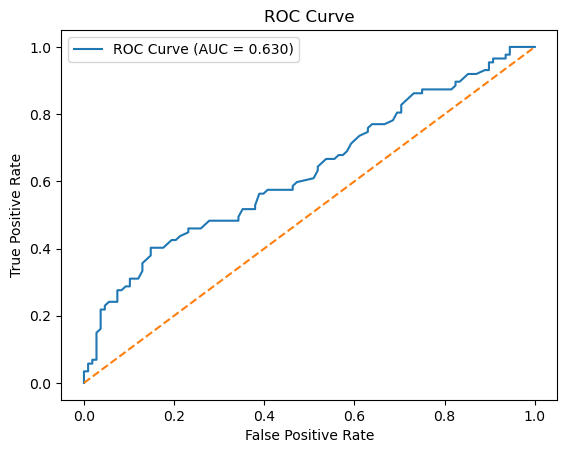

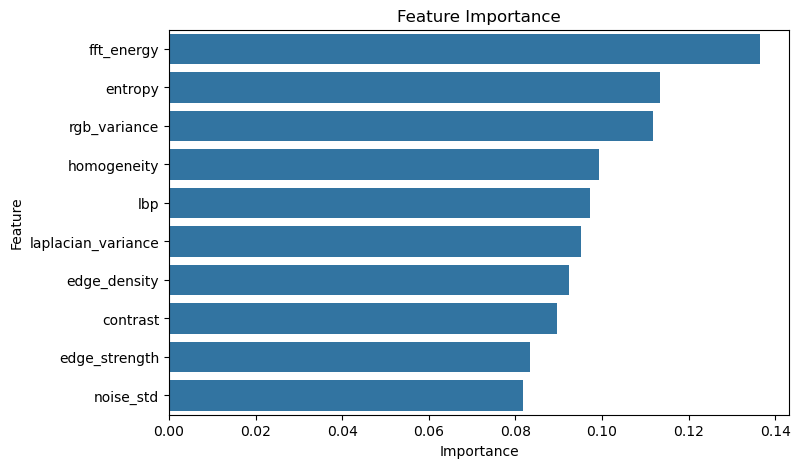


Cross-validation scores: [0.65641026 0.56923077 0.66666667 0.6        0.66666667]
Mean CV Accuracy: 0.6317948717948718


In [5]:
# ===================== COMPLETE RANDOM FOREST PIPELINE =====================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# -------------------- 1. LOAD DATA --------------------
df = pd.read_csv("Image_features_Dataset.csv")  # change path

# -------------------- 2. PREPROCESSING --------------------
# Separate features and label
X = df.drop("label", axis=1)
y = df["label"]

# Encode labels (Real=0, AI=1)
le = LabelEncoder()
y = le.fit_transform(y)

# Scale features (optional but good practice)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------- 3. TRAIN-TEST SPLIT --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------- 4. MODEL TRAINING --------------------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

# -------------------- 5. PREDICTIONS --------------------
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# -------------------- 6. EVALUATION METRICS --------------------
print("\n===== MODEL PERFORMANCE =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# -------------------- 7. CONFUSION MATRIX --------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real","AI"],
            yticklabels=["Real","AI"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------- 8. ROC CURVE --------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (AUC = %.3f)" % roc_auc_score(y_test, y_prob))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -------------------- 9. FEATURE IMPORTANCE --------------------
importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importance")
plt.show()

# -------------------- 10. CROSS-VALIDATION --------------------
cv_scores = cross_val_score(rf, X_scaled, y, cv=5)
print("\nCross-validation scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# ===================== END =====================